# Chapter 12 — Motion
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 12 — Motion.

On 10 June 2000 the London Millennium Footbridge swayed sideways under its opening-day crowd, and the engineers who diagnosed it worked from accelerometer records, turning measured motion into the force that caused it (Dallard et al., *The Structural Engineer* 79(22), 2001). This chapter follows the same chain on a small scale: motion becomes inertial force, force becomes bending strain at a gage, and how fast the force arrives decides how much strain the gage sees.

Everything here is computed from closed-form relations or from a single-degree-of-freedom model. The bracket is the chapter's worked example; nothing is measured data.

**This notebook demonstrates:**
1. The chapter's cantilever bracket: inertial force, root bending strain (Eq. 12.3), natural frequency (Eq. 12.4), and the sensitivity-versus-frequency trade-off.
2. The dynamic load factor for a ramp load (Eq. 12.5), checked against a direct numerical solution of the equation of motion.
3. Figure 12.1: the dynamic load factor against rise time, and the strain records of two brackets under the same 5 ms ramp.
4. What a 20 Hz low-pass filter and a 200 S/s channel do to the recorded peak of the 50 Hz bracket.

In [1]:
# !pip install numpy scipy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12, 'axes.titlesize': 12})

# Generated figures are written next to the chapter's other media.
# The file name matches the \includegraphics call in Chapter 12.
OUT_DIR = Path("../src/media/ch12")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1 — The bracket: from acceleration to strain

A mass $m$ at the free end of a cantilever of length $L$, width $b$ and thickness $h$ is accelerated at $a$. The inertial force $F = ma$ bends the cantilever, and the surface strain at the root is

$$\varepsilon = \frac{6\,m\,a\,L}{E\,b\,h^2} \qquad \text{(Eq. 12.3)}$$

The same cantilever, treated as a spring of stiffness $k = 3EI/L^3$ carrying the mass (its own mass neglected), has a first natural frequency

$$f_n = \frac{1}{2\pi}\sqrt{\frac{3EI}{mL^3}} \qquad \text{(Eq. 12.4)}$$

Dividing one by the other shows the trade-off every spring-mass sensor lives with: strain per unit acceleration equals $3h/(2L^2\omega_n^2)$, so for a given flexure shape it falls as the square of the natural frequency.

In [2]:
# Chapter 12 worked-example bracket (aluminum)
m = 2.5        # kg    mass at the free end
a = 12.0       # m/s^2 peak acceleration
L = 0.100      # m     cantilever length
b = 0.020      # m     width
h = 0.005      # m     thickness
E = 69e9       # Pa    elastic modulus of aluminum

F = m * a                          # N, inertial force
M = F * L                          # N*m, moment at the root
I = b * h**3 / 12                  # m^4
sigma = 6 * M / (b * h**2)         # Pa, outer-fiber stress = Mc/I with c = h/2
eps = sigma / E                    # strain

print(f"Inertial force           F = {F:.1f} N")
print(f"Root moment              M = {M:.2f} N*m")
print(f"Surface stress       sigma = {sigma/1e6:.1f} MPa ({sigma/6.894757e6:.2f} ksi)")
print(f"Surface strain         eps = {eps*1e6:.0f} microstrain")
print(f"Sensitivity                = {eps/a*1e6:.1f} microstrain per m/s^2 "
      f"({eps/a*9.80665*1e6:.0f} per g)")
print(f"Same force carried axially = {F/(b*h)/E*1e6:.1f} microstrain;  ratio 6L/h = {6*L/h:.0f}")

k = 3 * E * I / L**3               # N/m, tip stiffness
fn = np.sqrt(k / m) / (2 * np.pi)  # Hz
wn = 2 * np.pi * fn
print(f"\nTip stiffness            k = {k:,.0f} N/m")
print(f"Natural frequency       fn = {fn:.1f} Hz  (beam's own mass {2700*L*b*h*1000:.0f} g, neglected)")
print(f"Tip deflection at {a:.0f} m/s^2 = {a/wn**2*1000:.2f} mm")
print(f"Check: 3h/(2 L^2 wn^2)     = {3*h/(2*L**2*wn**2)*1e6:.1f} microstrain per m/s^2")

Inertial force           F = 30.0 N
Root moment              M = 3.00 N*m
Surface stress       sigma = 36.0 MPa (5.22 ksi)
Surface strain         eps = 522 microstrain
Sensitivity                = 43.5 microstrain per m/s^2 (426 per g)
Same force carried axially = 4.3 microstrain;  ratio 6L/h = 120

Tip stiffness            k = 43,125 N/m
Natural frequency       fn = 20.9 Hz  (beam's own mass 27 g, neglected)
Tip deflection at 12 m/s^2 = 0.70 mm
Check: 3h/(2 L^2 wn^2)     = 43.5 microstrain per m/s^2


## 2 — How fast the load arrives: the dynamic load factor

A load that ramps from zero to its final value in a rise time $t_r$ and then holds, applied to an undamped single-degree-of-freedom system of natural period $T$, produces a peak response

$$\mathrm{DLF} = 1 + \frac{\lvert\sin(\pi t_r/T)\rvert}{\pi t_r/T} \qquad \text{(Eq. 12.5)}$$

times the static response (Biggs, *Introduction to Structural Dynamics*, 1964). After the ramp ends the mass oscillates about the static position with amplitude $\lvert\sin(\pi t_r/T)\rvert/(\pi t_r/T)$, which is where the formula comes from. The cell below integrates the equation of motion directly and compares its peak with the formula, then adds 2% of critical damping (an assumed, typical value for a bolted metal bracket) to show how little light damping changes the first peak.

In [3]:
def dlf(ratio):
    # Peak dynamic load factor for an undamped ramp-and-hold load (Eq. 12.5)
    x = np.pi * np.asarray(ratio, dtype=float)
    return 1 + np.abs(np.sin(x)) / x


def ramp_response(f_n, zeta, t_r, t_end, n=6001):
    # Normalized response x(t)/x_static of a single-degree-of-freedom system
    # to a load that ramps linearly to its final value in t_r, then holds.
    w = 2 * np.pi * f_n
    def rhs(t, y):
        load = min(t / t_r, 1.0)
        return [y[1], w**2 * (load - y[0]) - 2 * zeta * w * y[1]]
    t = np.linspace(0, t_end, n)
    sol = solve_ivp(rhs, (0, t_end), [0.0, 0.0], t_eval=t,
                    max_step=t_r / 200, rtol=1e-9, atol=1e-12)
    return t, sol.y[0]


T_RISE = 0.005   # s, the chapter's 5 ms rise time
cases = {'50 Hz bracket': 50.0, '200 Hz bracket': 200.0, f'{fn:.0f} Hz bracket (Eq. 12.4)': fn}
for name, f in cases.items():
    _, x0 = ramp_response(f, 0.0, T_RISE, 0.3, n=60001)
    _, x2 = ramp_response(f, 0.02, T_RISE, 0.3, n=60001)
    print(f"{name:28s} t_r/T = {T_RISE*f:5.3f}   Eq. 12.5: {float(dlf(T_RISE*f)):.3f}"
          f"   simulated, undamped: {x0.max():.3f}   with 2% damping: {x2.max():.3f}")

50 Hz bracket                t_r/T = 0.250   Eq. 12.5: 1.900   simulated, undamped: 1.900   with 2% damping: 1.845


200 Hz bracket               t_r/T = 1.000   Eq. 12.5: 1.000   simulated, undamped: 1.000   with 2% damping: 1.018


21 Hz bracket (Eq. 12.4)     t_r/T = 0.105   Eq. 12.5: 1.982   simulated, undamped: 1.982   with 2% damping: 1.922


## 3 — Figure 12.1

Panel (a) plots Eq. 12.5 against the rise-time ratio, with the upper envelope $1 + 1/(\pi t_r/T)$ (capped at 2) that a designer uses when the natural frequency is known only roughly. Panel (b) shows the strain records themselves, normalized to the static strain, for the 50 Hz and 200 Hz brackets under the same 5 ms ramp with 2% damping. The open circles are what a channel sampling the 50 Hz bracket at 200 samples per second would record.

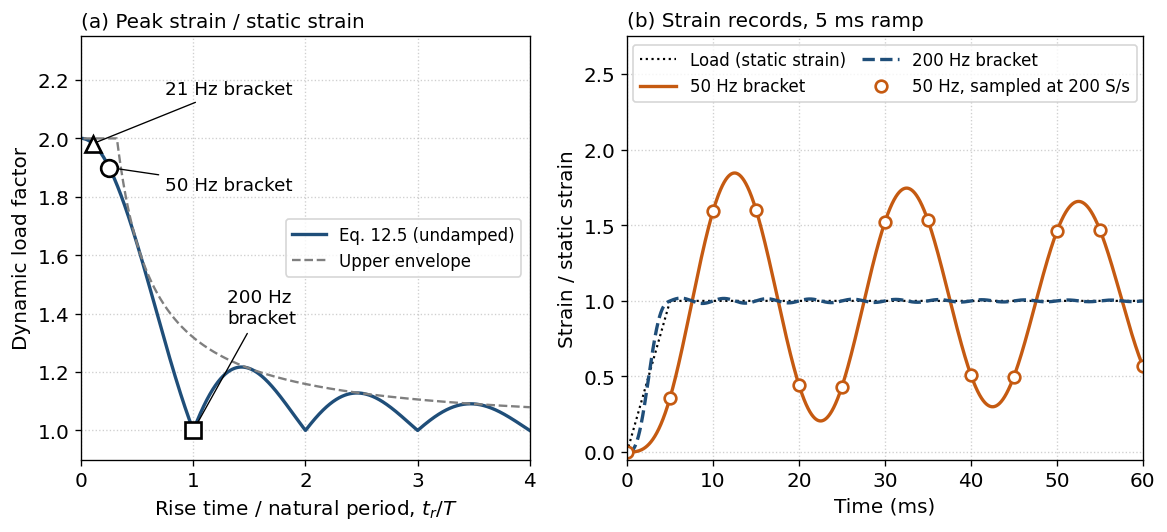

50 Hz bracket: true peak 1.845, largest sample at 200 S/s 1.603


In [4]:
f50, f200 = 50.0, 200.0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.6), gridspec_kw={'width_ratios': [1, 1.15]})

# (a) DLF against rise-time ratio
r = np.linspace(0.02, 4.0, 2000)
ax1.plot(r, dlf(r), color='#1f4e79', lw=2, label='Eq. 12.5 (undamped)')
ax1.plot(r, np.minimum(2, 1 + 1 / (np.pi * r)), color='#7f7f7f', lw=1.4, ls='--',
         label='Upper envelope')
pts = [(T_RISE * f50, '50 Hz bracket', 'o', (0.75, 1.84)),
       (T_RISE * f200, '200 Hz\nbracket', 's', (1.3, 1.42)),
       (T_RISE * fn, f'{fn:.0f} Hz bracket', '^', (0.75, 2.17))]
for x, lab, mk, txt in pts:
    y = float(dlf(x))
    ax1.plot(x, y, marker=mk, ms=10, mfc='white', mec='black', mew=1.6, ls='none', zorder=5)
    ax1.annotate(lab, xy=(x, y), xytext=txt, fontsize=11, va='center',
                 arrowprops=dict(arrowstyle='-', lw=0.8, color='black'))
ax1.set_xlim(0, 4)
ax1.set_ylim(0.9, 2.35)
ax1.set_xlabel(r'Rise time / natural period, $t_r/T$')
ax1.set_ylabel('Dynamic load factor')
ax1.set_title('(a) Peak strain / static strain', loc='left')
ax1.grid(True, ls=':', alpha=0.6)
ax1.legend(loc='center right', fontsize=10, frameon=True)

# (b) strain records under the same 5 ms ramp, 2% damping
t_end = 0.060
t, x50 = ramp_response(f50, 0.02, T_RISE, t_end)
_, x200 = ramp_response(f200, 0.02, T_RISE, t_end)
load = np.minimum(t / T_RISE, 1.0)
ax2.plot(t * 1e3, load, color='black', lw=1.3, ls=':', label='Load (static strain)')
ax2.plot(t * 1e3, x50, color='#c55a11', lw=2, ls='-', label='50 Hz bracket')
ax2.plot(t * 1e3, x200, color='#1f4e79', lw=2, ls='--', label='200 Hz bracket')
fs = 200.0                                     # samples per second
ts = np.arange(0, t_end + 1e-12, 1 / fs)
xs = np.interp(ts, t, x50)
ax2.plot(ts * 1e3, xs, ls='none', marker='o', ms=7, mfc='white', mec='#c55a11', mew=1.6,
         label='50 Hz, sampled at 200 S/s')
ax2.set_xlim(0, t_end * 1e3)
ax2.set_ylim(-0.05, 2.75)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Strain / static strain')
ax2.set_title('(b) Strain records, 5 ms ramp', loc='left')
ax2.grid(True, ls=':', alpha=0.6)
ax2.legend(loc='upper center', fontsize=10, ncol=2, frameon=True, columnspacing=1.0, handlelength=2.2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig12_nb1_ramp_load_response.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"50 Hz bracket: true peak {x50.max():.3f}, largest sample at {fs:.0f} S/s {xs.max():.3f}")

## 4 — What a low-pass filter does to the peak

The chapter warns that a filter set below the bracket's natural frequency removes the overshoot. The cell below passes the 50 Hz bracket's record (2% damping) through a four-pole Butterworth low-pass filter at 20 Hz, both zero-phase (`filtfilt`, as in post-processing) and causal (`lfilter`, as in a real-time acquisition filter), and compares the recorded peak with the true one. A long record is used so the filter's start-up transient settles.

In [5]:
from scipy.signal import butter, filtfilt, lfilter

t_long, x_long = ramp_response(50.0, 0.02, T_RISE, 0.5, n=50001)
fs_sim = 1 / (t_long[1] - t_long[0])
b_lp, a_lp = butter(4, 20.0 / (fs_sim / 2))
zero_phase = filtfilt(b_lp, a_lp, x_long).max()
causal = lfilter(b_lp, a_lp, x_long).max()
true_peak = x_long.max()
print(f"True peak (static = 1):          {true_peak:.3f}")
print(f"20 Hz 4-pole Butterworth, zero-phase: {zero_phase:.3f}  ({(1 - zero_phase/true_peak)*100:.0f}% low)")
print(f"20 Hz 4-pole Butterworth, causal:     {causal:.3f}  ({(1 - causal/true_peak)*100:.0f}% low)")

True peak (static = 1):          1.845
20 Hz 4-pole Butterworth, zero-phase: 1.079  (42% low)
20 Hz 4-pole Butterworth, causal:     1.139  (38% low)


## Where to take this next

1. **Sweep the damping.** Re-run panel (b) with damping of 0.5%, 5% and 20% of critical. The first peak barely moves until damping is large; what changes is how long the ringing lasts. The Millennium Bridge, measured at 0.6 to 0.8% of critical before its retrofit and designed for more than 20% after it, spans that whole range.
2. **Move the sample rate.** Change `fs` in the figure cell to 100, 500 and 1,000 samples per second and compare the largest sample with the true peak. Chapter 32 derives the worst-case shortfall, $1-\cos(\pi/N)$ for $N$ samples per cycle.
3. **Move the filter.** In Section 4, raise the cutoff to 50, 100 and 250 Hz and watch the recorded peak return toward 1.85 as the cutoff moves above the 50 Hz natural frequency.
4. **Redesign the bracket.** Using the cell in Section 1, find the thickness $h$ that raises the bracket's natural frequency to 200 Hz, and see what it costs in microstrain per m/s$^2$.